# Sprint 2 — Analisi Esplorativa e Outlier

> 📊 **Dataset**: UCI Machine Learning Repository — *Predict Students'
> Dropout and Academic Success* (3.630 studenti dopo rimozione Enrolled, 36 feature + 1 target).
> 🔗 https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

## Obiettivo del notebook

Questo notebook copre le **User Story di Sprint 2** del progetto di
predizione del dropout universitario. Lo scopo dello Sprint è esplorare
visivamente il dataset preprocessato in Sprint 1, identificare pattern
di distribuzione, correlazioni e outlier, in vista del modeling (Sprint 3).

In altre parole: alla fine di questo notebook avremo una comprensione
qualitativa di quali variabili discriminano meglio tra `Dropout` e `Graduate`,
quali sono ridondanti tra loro, e quali osservazioni anomale richiedono
attenzione prima del training.

## Indice e responsabilità

| # | User Story | Responsabile |
|---|---|---|
| 1 | [US-07 · Distribuzione delle variabili numeriche per classe target](#us-07) | Jessica |
| 2 | [US-08 · Analisi delle variabili categoriche](#us-08) | Youssra |
| 3 | [US-09 · Matrice di correlazione](#us-09) | Jessica & Youssra |
| 4 | [US-10 · Outlier per deviazione standard](#us-10) | Youssra |
| 5 | [US-11 · Outlier IQR/Boxplot](#us-11) | Jessica |
| 6 | [US-12 · Outlier DBSCAN](#us-12) | Youssra |
| 7 | [US-13 · Isolation Forest e confronto finale](#us-13) | Jessica |

## Note sull'esecuzione

- **Dataset di partenza**: `../data/processed/data_clean.csv`, prodotto al termine del notebook `01_preliminary_analysis.ipynb`.
- **Esecuzione lineare**: le celle vanno eseguite in ordine, dall'alto verso il basso. Ogni US assume che le precedenti siano state eseguite.
- **Output dei grafici**: salvati in `outputs/figures/` con naming `usXX_<descrizione-kebab-case>.png`.
- **Funzioni riutilizzabili**: importate da `src/` quando applicabile.

---

## Setup

Dipendenze del notebook. Le librerie sono elencate in `requirements.txt`
e vanno installate nel virtual env del progetto prima di eseguire le
celle successive.

In [ ]:
# Standard library
import math
import os
import sys

# Aggiungi la root del progetto al path Python, così che `src` sia importabile
sys.path.insert(0, os.path.abspath('..'))

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

# Local
from src.visualization import plot_numeric_by_target, DEFAULT_DISPLAY_NAMES

## Caricamento del dataset processato

Il dataset di partenza è quello esportato al termine del notebook
`01_preliminary_analysis.ipynb`: 3.630 studenti, 37 colonne (36 feature
rinominate in `snake_case` + 1 target binario), nessun missing value,
nessun duplicato.

In [2]:
# Caricamento del dataset processato a valle dello Sprint 1
df = pd.read_csv('../data/processed/data_clean.csv')

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
df.head()

Dataset caricato: 3630 righe, 37 colonne


,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nationality,mothers_qualification,fathers_qualification,...,cu_2nd_sem_credited,cu_2nd_sem_enrolled,cu_2nd_sem_evaluations,cu_2nd_sem_approved,cu_2nd_sem_grade,cu_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0


---

## US-07 · Distribuzione delle Variabili Numeriche per Classe Target <a id="us-07"></a>

**Responsabile**: Jessica M Pucci

### Obiettivo
Visualizzare con istogrammi separati per classe target (`Dropout` vs `Graduate`)
la distribuzione delle variabili numeriche più rilevanti del dataset, per
identificare quali caratteristiche distinguono maggiormente i due gruppi e
quali invece si sovrappongono.

### Approccio
1. **Selezione delle variabili numeriche rilevanti** — escludendo le variabili
   "categoriche camuffate da numero" (codici corso, codici nazionalità, ecc.)
2. **Visualizzazione comparativa** per classe target con istogrammi sovrapposti
3. **Osservazione qualitativa** per ciascun grafico: la variabile distingue le classi? quanto?
4. **Salvataggio** dei grafici in `outputs/figures/` per uso in presentazione finale

### 1.0 Selezione delle variabili numeriche

Tra le 36 feature del dataset, molte sono codici numerici di natura
categorica (es. `course`, `nacionality`, `marital_status`) e non sono
adatte a essere visualizzate come distribuzioni continue. Sono state
selezionate **8 variabili numeriche realmente continue**, scelte per
coprire diverse dimensioni del problema, organizzate in un ordine
narrativo che procede dall'identità dello studente alla sua evoluzione
accademica fino al contesto economico:

| # | Variabile | Categoria | Motivazione |
|---|---|---|---|
| 1 | `previous_qualification_grade` | Bagaglio iniziale | Voto della qualifica precedente all'ingresso universitario |
| 2 | `admission_grade` | Selezione universitaria | Voto di ammissione al corso scelto — predittore classico di successo accademico |
| 3 | `age_at_enrollment` | Demografica | Età all'iscrizione — coorti più mature hanno spesso percorsi e priorità diversi |
| 4 | `cu_1st_sem_approved` | Performance precoce (quantità) | Esami superati al 1° semestre — primo segnale concreto di tenuta |
| 5 | `cu_2nd_sem_approved` | Performance media (quantità) | Esami superati al 2° semestre — conferma o ribaltamento del trend iniziale |
| 6 | `cu_1st_sem_grade` | Performance precoce (qualità) | Voto medio al 1° semestre — misura qualitativa precoce |
| 7 | `cu_2nd_sem_grade` | Performance media (qualità) | Voto medio al 2° semestre — misura qualitativa al consolidarsi del percorso |
| 8 | `inflation_rate` | Macroeconomica | Tasso di inflazione del paese all'iscrizione — fattore di contesto esterno |

> 📐 **Nota sulla scala dei voti**: nel dataset alcuni voti sono espressi
> su scala 0-200, equivalente al sistema portoghese 0-20 moltiplicato per 10.
> La sufficienza è 100 (10/20) con eccezioni a 95 (9.5/20), voti buoni dai
> 140 (14/20), ottimi dai 180 (18/20). La mediana statistica nel sistema
> portoghese si attesta intorno a 133 (13.3/20).

In [3]:
# Variabili numeriche selezionate per US-07.
# Ordine narrativo: identità → evoluzione accademica → contesto.
numeric_features_to_plot = [
    'previous_qualification_grade',
    'admission_grade',
    'age_at_enrollment',
    'cu_1st_sem_approved',
    'cu_2nd_sem_approved',
    'cu_1st_sem_grade',
    'cu_2nd_sem_grade',
    'inflation_rate',
]

# Verifica colonne
missing_in_df = [c for c in numeric_features_to_plot if c not in df.columns]
if missing_in_df:
    print(f"⚠️  Colonne dichiarate ma non presenti nel df: {missing_in_df}")
else:
    print(f"✅  Tutte le {len(numeric_features_to_plot)} colonne sono presenti nel df.")

✅  Tutte le 8 colonne sono presenti nel df.


In [4]:
# Configurazione di bin e tick per ciascuna variabile.
# Decisa in fase di esplorazione visiva, valori specifici per scala e dominio.
BIN_WIDTHS = {
    'previous_qualification_grade':  5,
    'admission_grade':               5,
    'age_at_enrollment':             1,
    'cu_1st_sem_approved':           1,
    'cu_2nd_sem_approved':           1,
    'cu_1st_sem_grade':              0.5,
    'cu_2nd_sem_grade':              0.5,
    'inflation_rate':                0.5,
}

XTICK_STEPS = {
    'previous_qualification_grade':  10,
    'admission_grade':               10,
    'age_at_enrollment':             10,
    'cu_1st_sem_approved':           5,
    'cu_2nd_sem_approved':           5,
    'cu_1st_sem_grade':              None,
    'cu_2nd_sem_grade':              None,
    'inflation_rate':                1,
}

# Tick custom per le variabili che usano soglie semantiche
XTICKS_CUSTOM = {
    'cu_1st_sem_grade': [0, 5, 10, 15, 20],
    'cu_2nd_sem_grade': [0, 5, 10, 15, 20],
}

# Coppie di variabili da confrontare visivamente con scale identiche
_pair_grades = ['previous_qualification_grade', 'admission_grade']
_pair_approved = ['cu_1st_sem_approved', 'cu_2nd_sem_approved']
_pair_sem_grades = ['cu_1st_sem_grade', 'cu_2nd_sem_grade']

# Range delle coppie
XLIM_GRADES_200 = (90, 200)
XLIM_APPROVED = (0, df[_pair_approved].max().max() + 1)


def plot_from_config(column: str):
    """
    Chiama plot_numeric_by_target con i parametri di bin/tick/range
    presi dai dizionari di configurazione e dalle coppie definite sopra.
    """
    if column in _pair_grades:
        xlim, ylim = XLIM_GRADES_200, (0, 0.08)
    elif column in _pair_approved:
        xlim, ylim = XLIM_APPROVED, (0, 0.55)
    elif column in _pair_sem_grades:
        xlim, ylim = None, (0, 1.10)
    else:
        xlim, ylim = None, None

    return plot_numeric_by_target(
        df,
        column=column,
        bin_width=BIN_WIDTHS[column],
        xtick_step=XTICK_STEPS[column],
        xticks_custom=XTICKS_CUSTOM.get(column),
        xlim=xlim,
        ylim=ylim,
    )

### 1.1 Voto della qualifica precedente

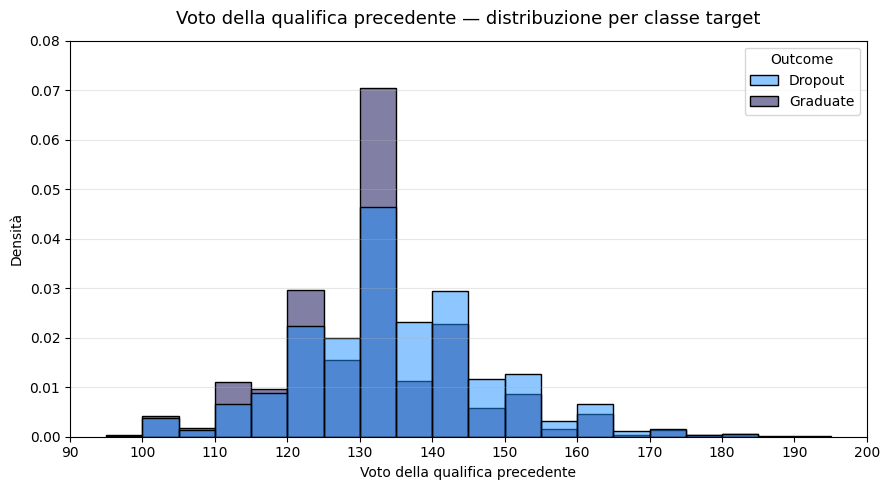

In [5]:
fig = plot_from_config('previous_qualification_grade')

Le distribuzioni di Dropout e Graduate sono ampiamente sovrapposte, segno che 
il voto della qualifica precedente non discrimina nettamente le due classi.

Entrambe piccano nella fascia 130-135, in corrispondenza della mediana del 
sistema scolastico portoghese (≈133). Il picco dei Dropout è leggermente più 
alto di quello dei Graduate, suggerendo che la maggioranza degli studenti 
"medi" finisce poi per abbandonare.

A sinistra del picco, nella fascia 110-125 (voti appena sopra la sufficienza), 
i Dropout dominano con densità maggiore. A destra del picco, nella fascia 
135-170 (voti buoni e molto buoni), il pattern si inverte e prevalgono i 
Graduate. Le code estreme (sotto 105 e sopra 175) sono basse per entrambi e 
mostrano sovrapposizione.

Gli studenti che entrano all'università con un bagaglio scolastico debole 
tendono leggermente più al dropout, ma la maggior parte di entrambi i gruppi 
condivide la zona della mediana. La differenza c'è, ma è modesta.

**Potere discriminante**: basso.

### 1.2 Voto di ammissione

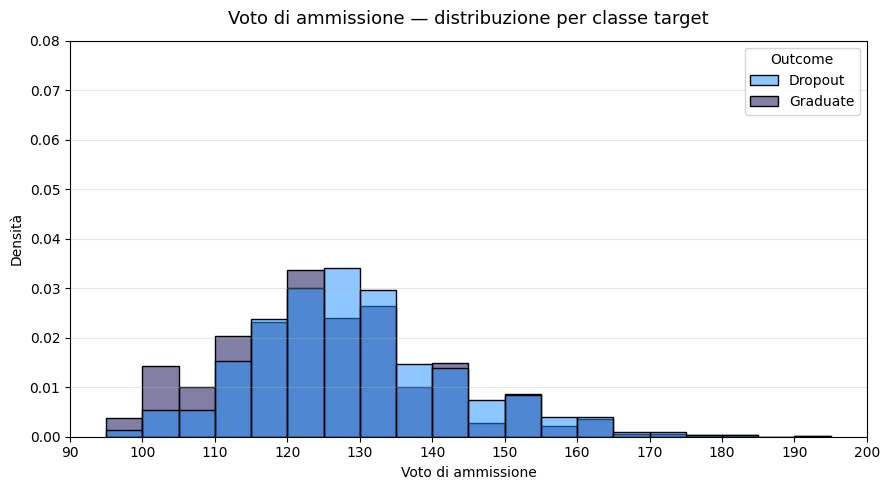

In [6]:
fig = plot_from_config('admission_grade')

A differenza del voto precedente, il voto di ammissione discrimina più 
nettamente tra le due classi. Le distribuzioni si sovrappongono meno e 
mostrano un'asimmetria positiva (coda lunga a destra, fino a circa 190).

I picchi sono distinti e leggermente sfasati: i Graduate concentrano la 
massa fra 125 e 130 (densità ≈0.034), i Dropout fra 120 e 125 (≈0.033), 
entrambe nella fascia sufficiente ma con i Dropout spostati di circa 5 
punti più in basso.

I Graduate dominano nella fascia 130-160 (voti da sufficiente fascia 
alta a molto buoni), mentre i Dropout prevalgono fra 100 e 120 
(sufficienza fascia bassa). La coda estrema oltre 160 è molto rara e 
mostra sovrapposizione tra i due gruppi.

Il voto di ammissione separa le due classi più nettamente del voto della 
qualifica precedente: probabilmente perché riflette la performance dello 
studente al momento dell'ingresso universitario, già più predittiva del 
successo accademico futuro.

**Potere discriminante**: medio-basso.

### 1.3 Età all'iscrizione

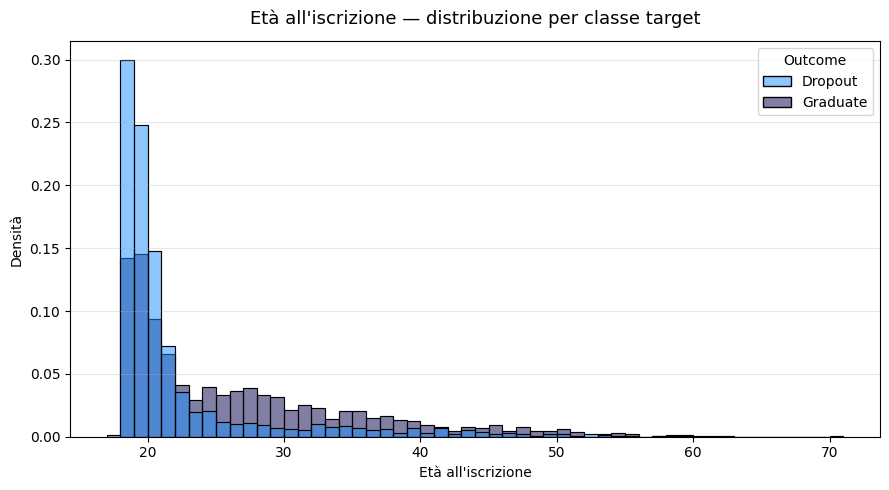

In [7]:
fig = plot_from_config('age_at_enrollment')

La distribuzione mostra una separazione apparentemente chiara tra le due 
classi in funzione dell'età all'iscrizione, con un punto di inversione 
intorno ai 22 anni. La **forma generale** delle due distribuzioni è 
simile — entrambe con picco fra 18 e 19 anni e coda asimmetrica verso 
età maggiori — ma con densità proporzionalmente differenti nelle varie 
fasce.

Il 75% dei Graduate rientra nella fascia 18-21 anni, mentre la stessa 
percentuale di Dropout si estende fino ai 30 anni: i secondi sono più 
spalmati su un range anagrafico ampio.

Nella fascia 18-20 — l'età "tipica" di ingresso post-superiori — i 
Graduate dominano nettamente, con un picco a 18 anni (densità ≈0.30) 
circa il doppio di quello dei Dropout (≈0.14). A partire dai 22 anni 
il pattern si inverte e i Dropout prevalgono in modo costante, con 
densità che decresce gradualmente all'aumentare dell'età (da ≈0.04 a 
22 anni fino a ≈0.01 a 40 anni). Oltre i 41 anni la coda assume un 
pattern frammentato per entrambe le classi.

Gli studenti che si iscrivono in età non tradizionale incontrano 
maggiori difficoltà a completare il percorso. Diverse ipotesi possono 
spiegare il fenomeno — responsabilità lavorative e familiari concorrenti 
con lo studio, minore disponibilità di tempo, pressioni economiche più 
dirette — ma il dataset non permette di distinguere tra queste cause. 
Resta un'osservazione importante per le politiche di supporto: studenti 
maturi potrebbero necessitare di servizi dedicati per ridurre il rischio 
di abbandono.

**Potere discriminante**: medio-alto.

### 1.4 Esami superati al 1° semestre

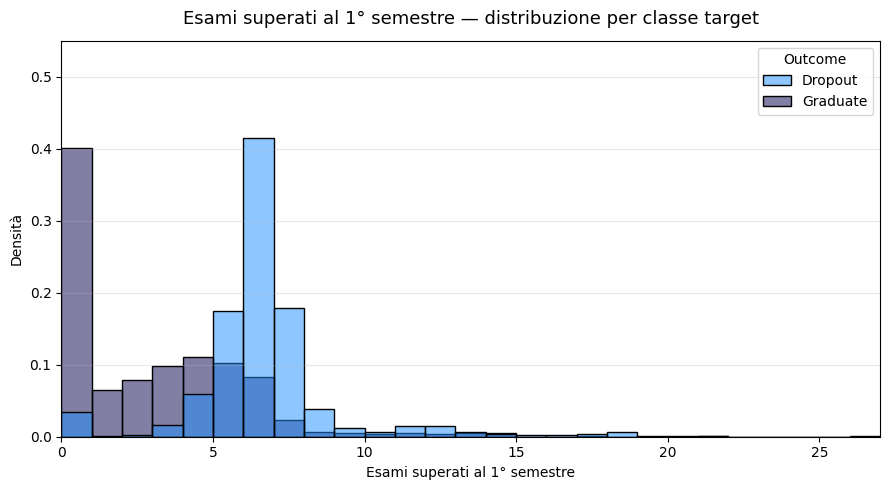

In [8]:
fig = plot_from_config('cu_1st_sem_approved')

Il numero di esami superati al 1° semestre mostra il pattern più marcato 
finora osservato: il picco a 0 esami è dominato dai Dropout con densità 
≈0.40, contro un irrisorio ≈0.04 dei Graduate — un rapporto di circa 10 
a 1.

I Graduate, al contrario, si concentrano fortemente nella fascia 5-7 
esami superati, con un picco netto a 6 (≈0.41). Senza informazioni 
specifiche sui piani di studio dei diversi corsi presenti nel dataset, 
si può ipotizzare che il valore 6 rappresenti il numero più frequente 
di esami previsti al 1° semestre tra i corsi considerati: gli studenti 
che lo raggiungono sono quelli che riescono a sostenere il carico 
accademico nei tempi previsti, indipendentemente dal corso specifico.

Tra 1 e 4 esami i Dropout dominano in modo costante (rapporti tipici 2-5x 
rispetto ai Graduate), con picchi secondari a 3 (D ≈0.10, G ≈0.02) e a 4 
(D ≈0.115, G ≈0.06). A partire da 5 esami il pattern si attenua e si 
inverte: i Graduate iniziano a prevalere e mantengono la dominanza fino 
agli 11-12 esami, oltre i quali la distribuzione diventa sparsa.

Il numero di esami superati al 1° semestre è uno dei segnali predittivi 
più forti dell'intero dataset: già entro la fine del primo periodo 
accademico, gli studenti che hanno superato pochi o zero esami mostrano 
un rischio di abbandono nettamente superiore. Questo è un dato cruciale 
per qualunque sistema di intervento precoce.

**Potere discriminante**: alto.

### 1.5 Esami superati al 2° semestre

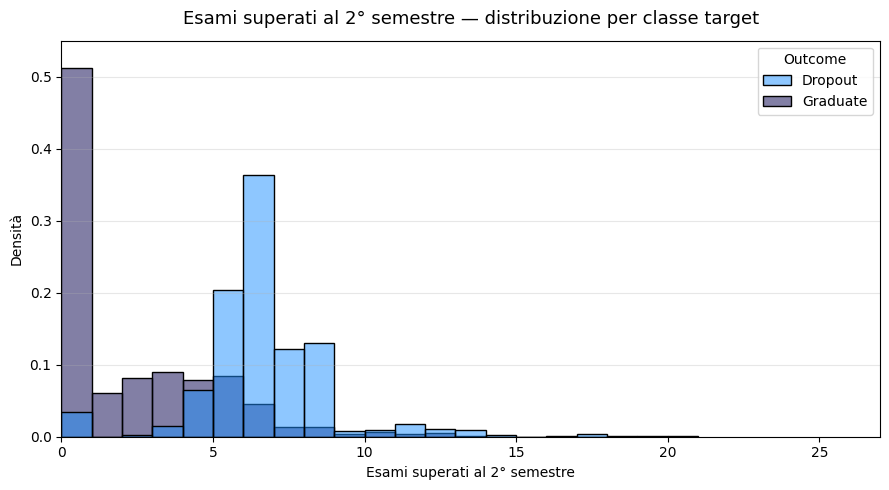

In [9]:
fig = plot_from_config('cu_2nd_sem_approved')

Al 2° semestre il pattern del 1° si conferma e si intensifica. Il picco 
Dropout a 0 esami sale a densità ≈0.51 (contro ≈0.40 del 1° semestre), 
mentre il picco Graduate resta a 6 esami con densità ≈0.36 (contro 
≈0.41 del 1° sem). La distanza tra le due classi nei valori estremi 
diventa quindi ancora più marcata.

Tra 1 e 4 esami i Dropout continuano a dominare, con un pattern simile 
a quello del 1° semestre ma con densità leggermente inferiori — segno 
che la massa di Dropout si sta progressivamente concentrando sul 
"valore 0". A partire da 5 esami i Graduate prevalgono nettamente, con 
la fascia 5-7 ancora come zona di concentrazione principale.

Il pattern del 1° semestre, già fortemente discriminante, si conferma 
e si rafforza al 2°. È importante notare che i conteggi del 1° e del 
2° semestre sono indipendenti: un valore alto a "0 esami superati" 
non significa che gli stessi studenti restano fermi, ma che — come 
gruppo — i Dropout si concentrano sempre di più sul valore 0 al 2° 
semestre. Senza un'analisi longitudinale individuale non possiamo 
distinguere se siano gli stessi studenti del 1° semestre a non 
superare nulla anche al 2° o se nuovi studenti "scivolino" verso 
quel valore. Quel che si osserva è che la massa Dropout si 
intensifica nella zona di rischio massimo, e questo rafforza l'idea 
che intervenire già a metà del primo anno possa essere efficace.

**Potere discriminante**: alto.

### 1.6 Voto medio al 1° semestre

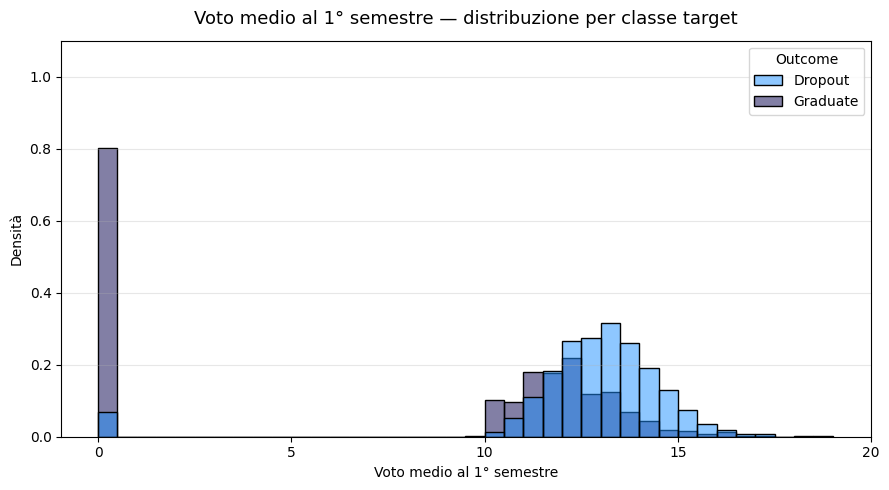

In [10]:
fig = plot_from_config('cu_1st_sem_grade')

Il voto medio del 1° semestre mostra un picco a 0 dominato dai Dropout 
(densità ≈0.80) contro un irrisorio ≈0.08 dei Graduate — un rapporto 
di circa 10 a 1, che prevedibilmente riflette il pattern già visto nel 
grafico degli esami superati al 1° semestre.

Tra 0.5 e 9 non compaiono valori: questo riflette la policy del 
sistema portoghese, dove la sufficienza è 10/20 (con eccezioni a 9.5). 
Quando uno studente non supera nessun esame, il voto medio del semestre 
viene registrato come 0 (placeholder convenzionale), non come un voto 
basso effettivo. Lo 0 è quindi semanticamente diverso dai voti reali 
nella fascia 10-20.

Nella fascia dei voti effettivi (10-20), i Graduate mostrano una 
distribuzione quasi a campana con picco a 13 (densità ≈0.30) e una 
coda che si estende fino a circa 18-19. I Dropout sono invece spostati 
verso sinistra, con picco a 12 (densità ≈0.22) e una coda più lunga 
verso destra. Il pattern di dominanza è netto: tra 10 e 11.5 prevalgono 
i Dropout, da 11.5 fino alla coda destra prevalgono i Graduate.

Il voto medio al 1° semestre conferma e completa il pattern visto sul 
numero di esami superati: oltre alla quantità (chi non supera 
abbandona), conta anche la qualità (chi supera meno bene tende 
all'abbandono). Insieme, le due dimensioni delineano un profilo di 
rischio già leggibile a metà del primo anno.

**Potere discriminante**: alto.

### 1.7 Voto medio al 2° semestre

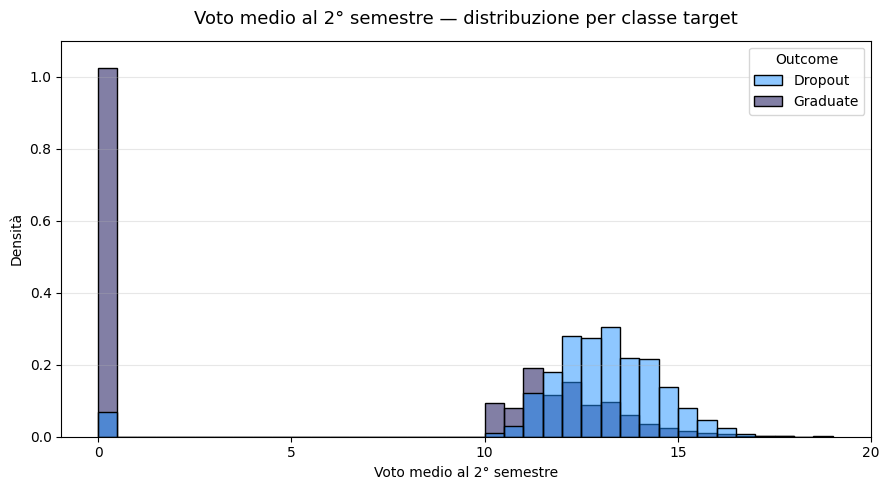

In [11]:
fig = plot_from_config('cu_2nd_sem_grade')

Anche al 2° semestre il picco a 0 dei Dropout (densità ≈1.02) riflette 
lo stesso fenomeno visto nel grafico degli esami superati al 2° 
semestre: gli studenti che non hanno superato alcun esame del semestre 
vengono registrati con voto medio 0 (placeholder). I due indicatori 
(`*_approved=0` e `*_grade=0`) misurano essenzialmente lo stesso 
fenomeno e dovranno essere trattati con cautela in fase di feature 
engineering, per evitare che lo stesso segnale venga pesato due volte 
nel modello (riflessione che riprenderemo in Sprint 3, US-13).

Tra 0.5 e 9 la zona resta vuota per lo stesso motivo metodologico già 
discusso al 1° semestre. Nella fascia dei voti effettivi (10-20) il 
pattern del 1° semestre si rafforza ulteriormente: i Graduate mantengono 
il picco a 13 con densità ≈0.30, mentre i Dropout mostrano un picco 
spostato a 11 con densità ≈0.18 — leggermente più basso e più a 
sinistra rispetto al 1° semestre, dove era a 12 con densità ≈0.22.

Il pattern del 1° semestre si conferma e si intensifica al 2°, ma anche 
qui vale la cautela metodologica: senza un'analisi longitudinale 
individuale non possiamo dire se siano gli stessi studenti a 
"scivolare" verso voti più bassi o se la composizione del gruppo 
Dropout cambi tra i due semestri. Quel che si osserva è che, come 
gruppo, i Dropout si concentrano sempre di più nella fascia di voti 
appena sufficienti, mentre i Graduate mantengono la loro posizione 
qualitativa.

La coppia voti medi 1° e 2° semestre, insieme alla coppia esami 
superati, delinea un profilo di rischio chiaro e leggibile entro la 
fine del primo anno: chi va male in quantità, va male anche in qualità 
— e il pattern si rafforza nel tempo.

**Potere discriminante**: alto.

### 1.8 Tasso di inflazione

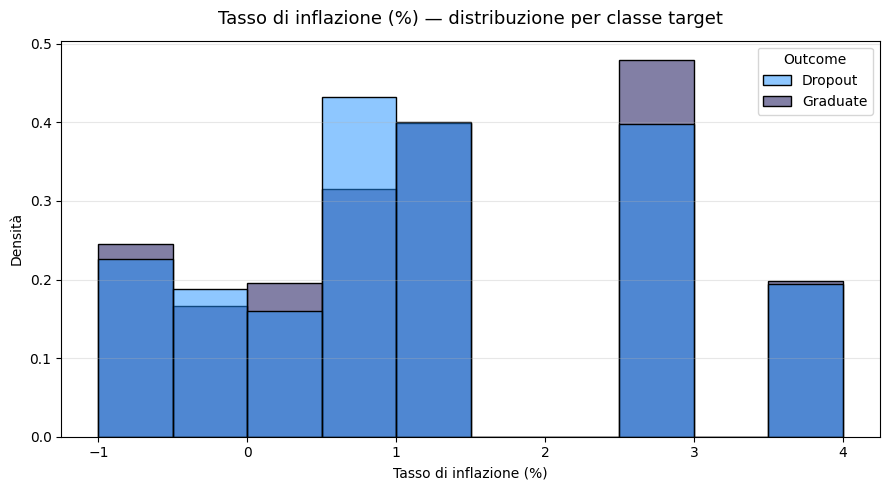

In [12]:
fig = plot_from_config('inflation_rate')

L' `inflation_rate` rappresenta la variazione percentuale annua dei 
prezzi al consumo nel paese, misurata nell'anno di iscrizione di ciascuno 
studente. Si tratta di un indicatore di contesto: tutti gli studenti 
iscritti nello stesso anno condividono lo stesso valore.

Nel dataset il tasso varia tra -0.8% (deflazione) e +3.7% (inflazione 
elevata), con 10 valori distinti corrispondenti ad altrettanti anni di 
iscrizione presenti nei dati. Questa **discretizzazione per coorte** è 
un limite intrinseco dell'analisi: il grafico mostra differenze tra 
anni, non tra studenti, e poiché gli anni distinti sono solo 10 il 
pattern statistico va letto con grande cautela.

**Perché abbiamo incluso questa variabile.** Le altre sette variabili 
selezionate sono tutte di natura individuale (caratteristiche dello 
studente o della sua performance accademica). Includere un indicatore 
di contesto economico permette di non ridurre il dropout a un fenomeno 
puramente personale e di dare una lettura più ampia al pubblico della 
presentazione. La fragilità statistica è un limite che dichiariamo 
apertamente, non un motivo per escludere l'osservazione.

Detto questo, si osservano alcuni segnali deboli ma coerenti:
- A inflazione moderata-bassa (0.5-1%) i Graduate dominano (≈0.43 contro 
  ≈0.32 dei Dropout)
- A inflazione elevata (3-3.5%) il pattern si inverte e i Dropout 
  prevalgono (≈0.48 contro ≈0.40 dei Graduate)
- Nei valori intermedi e nelle code estreme le distribuzioni sono 
  sostanzialmente sovrapposte

L'ipotesi narrativa sostenibile — non statisticamente provata — è che 
periodi di pressione economica più intensa (inflazione alta) si associno 
a una leggera maggior frequenza di abbandono. Una conferma rigorosa 
richiederebbe però decadi di dati e un'analisi temporale dedicata, 
fuori dallo scopo di questo progetto. La variabile resta utile per una 
lettura **sistemica** del fenomeno dropout, ma non per una predizione 
individuale.

**Potere discriminante**: basso.

### Sintesi US-07

#### Potere discriminante delle 8 variabili

| Variabile | Potere discriminante | Note |
|---|---|---|
| Esami superati al 1° semestre | **Alto** | Pattern più marcato: rapporto 10:1 al picco a 0 esami |
| Esami superati al 2° semestre | **Alto** | Conferma e intensifica il pattern del 1° semestre |
| Voto medio al 1° semestre | **Alto** | Lo 0 è categoria semantica (nessun esame superato) |
| Voto medio al 2° semestre | **Alto** | Conferma il pattern qualitativo del 1° semestre |
| Età all'iscrizione | **Medio-alto** | Inversione netta a 22 anni; cautela etica nella lettura |
| Voto di ammissione | **Medio-basso** | Distribuzioni parzialmente sovrapposte, picchi sfasati |
| Voto della qualifica precedente | **Basso** | Distribuzioni ampiamente sovrapposte |
| Tasso di inflazione | **Basso** | Limitato dalla discretizzazione per coorte (10 anni) |

#### Pattern emergenti

**La performance accademica è il segnale più forte.** I quattro indicatori 
relativi al 1° e 2° semestre (esami superati e voto medio) presentano 
pattern di separazione netti tra Dropout e Graduate. Questo è il 
gruppo di variabili più predittivo dell'analisi.

**I quattro indicatori accademici sono però fortemente correlati.** I 
picchi a 0 di "esami superati" e "voto medio" misurano lo stesso 
fenomeno (nessun esame superato): in fase di feature engineering 
(Sprint 3, US-13) sarà importante valutare l'eliminazione o aggregazione 
di alcuni di questi indicatori per evitare ridondanza.

**Il pattern si rafforza dal 1° al 2° semestre.** Sia per gli esami 
superati che per i voti medi, la massa Dropout si concentra sempre di 
più sul valore 0 al 2° semestre. Questo suggerisce che un sistema di 
intervento precoce è efficacemente attuabile **già a metà del primo 
anno**, prima che la situazione si consolidi.

**L'età è discriminante ma va trattata con cautela.** La separazione 
delle classi è netta (punto di inversione a 22 anni), ma la forma delle 
distribuzioni è simile e la variabile è eticamente delicata: includerla 
nel modello richiederà una riflessione esplicita sui rischi di bias 
nelle previsioni.

**Il bagaglio scolastico precedente conta poco.** Voto della qualifica 
precedente e voto di ammissione mostrano sovrapposizioni significative. 
Suggerisce che il segnale di rischio dropout emerge **dentro** 
l'università, non fuori.

**L'inflazione fornisce contesto, non predizione.** La variabile è 
mantenuta nella narrativa per permettere una lettura sistemica del 
fenomeno (il dropout non è solo individuale), ma la sua fragilità 
statistica (10 anni di dati) ne limita l'utilità predittiva.

#### Implicazioni per il lavoro successivo

Dalle 8 variabili numeriche analizzate in questa sezione emergono 
tre profili rilevanti in vista delle fasi di feature selection e 
modeling dello Sprint 3:

- **Candidati forti per il modello**: esami superati e voti medi 
  (entrambi i semestri), età all'iscrizione
- **Candidati con cautela**: voto di ammissione, da valutare se 
  l'aggiunta produce un miglioramento marginale
- **Candidati deboli o problematici**: voto della qualifica 
  precedente (segnale debole), inflation rate (segnale debole e di 
  natura sistemica), e i quattro indicatori accademici da bilanciare 
  per evitare ridondanza

Queste considerazioni andranno integrate con le analisi delle altre 
sezioni di questo notebook (variabili categoriche, outlier, ecc.) 
prima di procedere alla feature selection statistica.

> 📌 **Nota per Sprint 3 (US-13 — feature selection)**: i quattro 
> indicatori `curricular_units_1st_sem_approved`, 
> `curricular_units_2nd_sem_approved`, `curricular_units_1st_sem_grade`, 
> `curricular_units_2nd_sem_grade` sono fortemente correlati (i picchi 
> a 0 di "approved" e "grade" misurano lo stesso fenomeno: nessun esame 
> superato). Considerare l'eliminazione o aggregazione di alcuni di 
> questi indicatori per evitare ridondanza nel modello.

### 1.9 Esportazione dei grafici

Salvataggio degli 8 grafici come PNG in `outputs/figures/` per uso in
presentazione finale.

In [14]:
# Salvataggio dei grafici come PNG in outputs/figures/
OUTPUT_DIR = '../outputs/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

for col in numeric_features_to_plot:
    fig = plot_from_config(col)
    filename = f"us07_{col.replace('_', '-')}.png"
    filepath = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.close(fig)  # libera memoria
    print(f"✓ Salvato: {filepath}")

✓ Salvato: ../outputs/figures\us07_previous-qualification-grade.png
✓ Salvato: ../outputs/figures\us07_admission-grade.png
✓ Salvato: ../outputs/figures\us07_age-at-enrollment.png
✓ Salvato: ../outputs/figures\us07_cu-1st-sem-approved.png
✓ Salvato: ../outputs/figures\us07_cu-2nd-sem-approved.png
✓ Salvato: ../outputs/figures\us07_cu-1st-sem-grade.png
✓ Salvato: ../outputs/figures\us07_cu-2nd-sem-grade.png
✓ Salvato: ../outputs/figures\us07_inflation-rate.png


---

## US-08 · Analisi delle Variabili Categoriche

**Responsabile**: Youssra Zarouky

Analisi della distribuzione di 4 variabili categoriche rispetto all'esito accademico. I grafici mostrano percentuali per permettere confronti equi.

In [ ]:
label_maps = {
    'gender': {0: 'Femmina', 1: 'Maschio'},
    'scholarship_holder': {0: 'No', 1: 'Sì'},
    'debtor': {0: 'No', 1: 'Sì'},
    'daytime_evening_attendance': {0: 'Serale', 1: 'Diurno'}
}

target_labels = {0: 'Graduate', 1: 'Dropout'}
variables = ['gender', 'scholarship_holder', 'debtor', 'daytime_evening_attendance']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables):
    ct = pd.crosstab(
        df[var].map(label_maps[var]),
        df['target'].map(target_labels),
        normalize='index'
    ) * 100
    ct.plot(kind='bar', ax=axes[i], color=['#3498db', '#85c1e9'], edgecolor='white')
    axes[i].set_title(DEFAULT_DISPLAY_NAMES.get(var, var.replace('_', ' ').title()), fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentuale (%)')
    axes[i].set_ylim(0, 100)
    axes[i].legend(title='Esito')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Variabili categoriche per esito accademico', fontsize=15, fontweight='bold')
plt.tight_layout()
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/us08_variabili_categoriche.png', dpi=150, bbox_inches='tight')
print('Grafico salvato.')

### Osservazioni

- **Gender**: le studentesse si laureano in percentuale piu alta rispetto agli studenti maschi.
- **Scholarship holder**: gli studenti con borsa di studio hanno una probabilita di laurea significativamente piu alta.
- **Debtor**: gli studenti con debiti hanno una probabilita di dropout molto piu alta. E la variabile con la separazione piu netta.
- **Daytime/Evening attendance**: gli studenti in frequenza diurna si laureano in percentuale leggermente piu alta rispetto a quelli serali.

---

---

## US-09 · Matrice di Correlazione

**Responsabile**: Youssra Zarouky

Analisi delle correlazioni di Pearson tra le variabili numeriche per identificare coppie ridondanti.

In [ ]:
import numpy as np

numerical_cols = [
    'previous_qualification_grade', 'admission_grade', 'age_at_enrollment',
    'cu_1st_sem_credited', 'cu_1st_sem_enrolled', 'cu_1st_sem_evaluations',
    'cu_1st_sem_approved', 'cu_1st_sem_grade', 'cu_1st_sem_without_evaluations',
    'cu_2nd_sem_credited', 'cu_2nd_sem_enrolled', 'cu_2nd_sem_evaluations',
    'cu_2nd_sem_approved', 'cu_2nd_sem_grade', 'cu_2nd_sem_without_evaluations',
    'unemployment_rate', 'inflation_rate', 'gdp'
]

corr_matrix = df[numerical_cols].corr()
corr_it = corr_matrix.rename(columns=DEFAULT_DISPLAY_NAMES, index=DEFAULT_DISPLAY_NAMES)
mask = np.triu(np.ones_like(corr_it, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_it, mask=mask, annot=False, cmap='coolwarm',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matrice di Correlazione di Pearson', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/us09_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap salvata.')

In [ ]:
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.8:
            high_corr_pairs.append({
                'variabile_1': corr_matrix.columns[i],
                'variabile_2': corr_matrix.columns[j],
                'correlazione': round(val, 3)
            })

df_high_corr = pd.DataFrame(high_corr_pairs).sort_values('correlazione', key=abs, ascending=False)
print('Coppie con correlazione > 0.8: ' + str(len(high_corr_pairs)))
print()
if len(high_corr_pairs) > 0:
    print(df_high_corr.to_string(index=False))
else:
    print('Nessuna coppia trovata.')

### Osservazioni

Le coppie con correlazione superiore a 0.8 rappresentano variabili che trasmettono informazioni simili. Tra le variabili del **1° e 2° semestre** ci aspettiamo alta correlazione: chi supera **più** esami tende ad avere voti **più** alti.

### Decisione
Le variabili altamente correlate non vengono rimosse ora. Saranno valutate nella US-14 (Preprocessing).